In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from scipy.integrate import solve_ivp
from os.path import join
plt.rcParams['figure.facecolor']='white'

# Solving simple ODEs by representing it as a linear PDE

In [20]:

N = 256
m = 1
R = 1

h = R/(N-1)
omega = (m * h) ** (1/2)

T = 1.0
N_t = 64
times = np.linspace(0, T, N_t)

x0_tmp, x1_tmp = np.meshgrid(np.linspace(0, R, N), np.linspace(0, R, N), indexing='ij')
X = np.stack([x0_tmp,x1_tmp], axis=-1)

X_0 = np.array([0.3, 0.7])

In [23]:
psi_0 = np.exp(-(np.linalg.norm((X[:,:] - X_0)/0.1, axis=2)**2))

delta_multivar(X - X_0, omega)
psi_0 /= np.linalg.norm(psi_0)

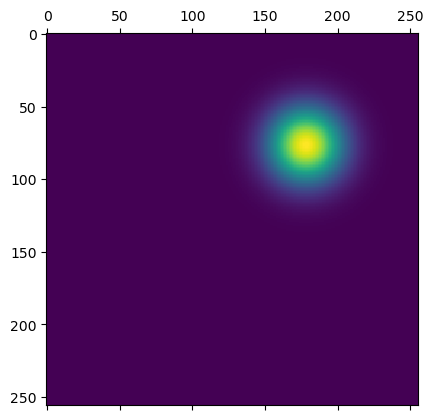

In [24]:
plt.matshow(psi_0)
plt.show()

In [25]:
psi_0_vec = psi_0.flatten(order="F")

In [26]:
x0 = np.linspace(0, R, N)
x1 = np.linspace(0, R, N)

x0_midpoints = np.zeros(N-1)
x1_midpoints = np.zeros(N-1)
for i in range(N-1):
    x0_midpoints[i] = (x0[i] + x0[i+1]) / 2
    x1_midpoints[i] = (x1[i] + x1[i+1]) / 2

In [27]:
dist_0 = np.abs(psi_0) ** 2

In [28]:
print(f"x0(t) = {np.sum(np.multiply(dist_0.T, x0)) : 0.2f}")
print(f"x1(t) = {np.sum(np.multiply(dist_0, x1)) : 0.2f}")

x0(t) =  0.30
x1(t) =  0.70


In [93]:
F0 = 0.2 * x0_midpoints + 0.1 * x1_midpoints
F1 = - 0.1 * x0_midpoints - 0.2 * x1_midpoints

# F2 = (0.5 * x0 + 0.2 * x1)[1:-1]
# F3 = (- 0.2 * x0 - 0.5 * x1)[1:-1]

F4 = F0[1:-1]
F5 = F1[1:-1]

In [94]:

# alternating_sign = np.array([(-1)**i for i in range(N-1)])

In [95]:
# omega_0 = 0.25 * F1 * alternating_sign / h
# H = driving_term(N-1, omega_0)

In [96]:
# H_sub = np.zeros((N,N), dtype=np.complex64)

# bitstring_1 = [k % 2 for k in range(N-1)]
# for i in range(N):

#     bitstring_2 = [k % 2 for k in range(N-1)]
#     for j in range(N):

#         H_sub[i,j] = H[bitstring_to_int(bitstring_1), bitstring_to_int(bitstring_2)]

#         if j < N-1:
#             bitstring_2[j] = 1 - bitstring_2[j]

#     if i < N-1:
#         bitstring_1[i] = 1 - bitstring_1[i]


In [97]:
# H_sub

In [98]:
# second order central differences
F0_operator = diags([-0.5j * F0, 0.5j * F0], offsets=[1 ,-1]) / (h)
F1_operator = diags([-0.5j * F1, 0.5j * F1], offsets=[1 ,-1]) / (h)

# fourth order central differences
# F0_operator = diags([-(2j/3) * F0, (2j/3) * F0, (1j/12) * F2, -(1j/12) * F2], offsets=[1 ,-1, 2, -2]) / h
# F1_operator = diags([-(2j/3) * F1, (2j/3) * F1, (1j/12) * F3, -(1j/12) * F3], offsets=[1 ,-1, 2, -2]) / h

# sixth order central differences
# F0_operator = diags([-(3j/4) * F0, (3j/4) * F0, (3j/20) * F2, -(3j/20) * F2, -(1/60) * F4, (1/60) * F4], offsets=[1 ,-1, 2, -2, 3, -3]) / h
# F1_operator = diags([-(3j/4) * F1, (3j/4) * F1, (3j/20) * F3, -(3j/20) * F3, -(1/60) * F5, (1/60) * F5], offsets=[1 ,-1, 2, -2, 3, -3]) / h

In [99]:
H = kron(np.eye(N), F0_operator) + kron(F1_operator, np.eye(N))

In [100]:
psi = expm_multiply(-1j * H, psi_0_vec, 0, T, N_t)

In [101]:
X_sol = np.zeros((N_t, 2))

In [102]:
for i in range(N_t):
    dist = np.reshape(np.abs(psi[i]) ** 2, (N,N), order="F")
    X_sol[i,0] = np.sum(np.multiply(dist.T, x0))
    X_sol[i,1] = np.sum(np.multiply(dist, x1))

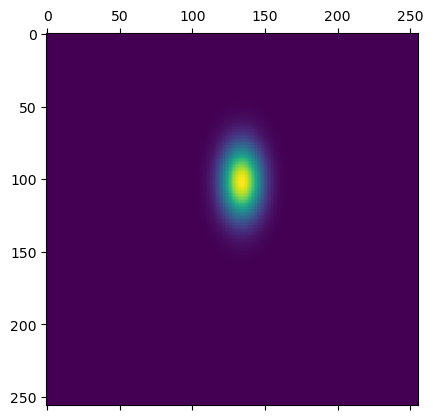

In [103]:

# time_index = 60

# fig, axs = plt.subplots(1, 1, constrained_layout=True, figsize=(10, 4))
# axs.flatten()

plt.matshow(np.reshape(np.abs(psi[time_index]) ** 2, (N,N), order="F"))
# axs[0].set_title("Discretized system")
# axs[1].matshow(np.abs(psi_ryd[time_index]) ** 2)
# axs[1].set_title("Rydberg simulation")
plt.show()

In [106]:
F = lambda t, X: [0.2 * X[0] + 0.1 * X[1], - 0.1 * X[0] - 0.2 * X[1]]
X_0 = [0.3, 0.7]

t_eval = np.linspace(0, T, N_t)
sol = solve_ivp(F, [0, T], X_0, t_eval=t_eval)

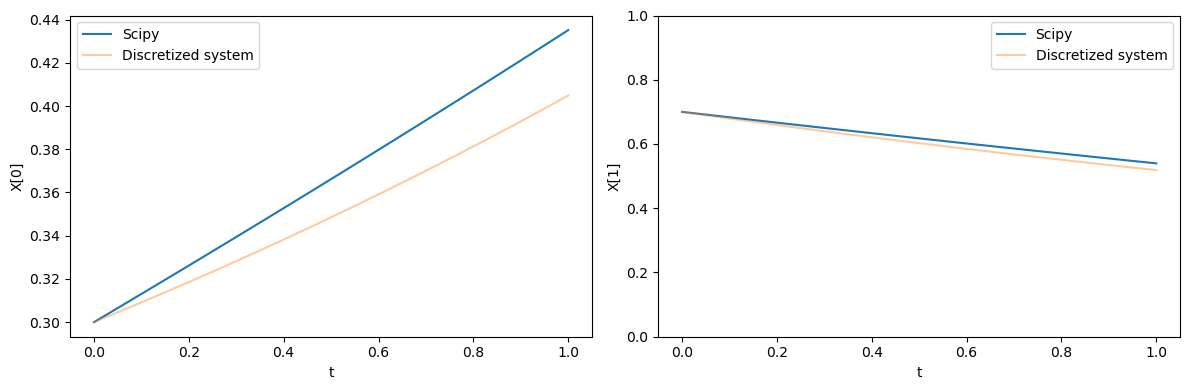

In [107]:
plt.figure(figsize = (12, 4))

plt.subplot(121)
plt.plot(sol.t, sol.y[0], "-", label="Scipy", markersize=2)
plt.plot(times, X_sol[:,0], "-", label="Discretized system", markersize=2, alpha=0.4)
# plt.plot(times, X_sol_ryd[:,0], "-", label=f"Rydberg simulation ({n_ryd+1} by {n_ryd+1} lattice)", markersize=2, alpha=0.4)
plt.legend()
plt.xlabel('t')
plt.ylabel('X[0]')

plt.subplot(122)
plt.plot(sol.t, sol.y[1], "-", label="Scipy", markersize=2)
plt.plot(times, X_sol[:,1], "-", label="Discretized system", markersize=2, alpha=0.4)
# plt.plot(times, X_sol_ryd[:,1], "-", label=f"Rydberg simulation", markersize=2, alpha=0.4)
plt.ylim(0,1)
plt.legend()
plt.xlabel('t')
plt.ylabel('X[1]')
plt.tight_layout()
plt.show()

In [34]:
use_ours = True

In [35]:
X0_derivative = np.zeros(N_t)
X1_derivative = np.zeros(N_t)

dt = T / (N_t - 1)
for i in range(1,N_t-1):
    if use_ours:
        X0_derivative[i] = (X_sol[i+1][0] - X_sol[i-1][0]) / (2 * (dt))
        X1_derivative[i] = (X_sol[i+1][1] - X_sol[i-1][1]) / (2 * (dt))
    else:
        X0_derivative[i] = (sol.y[0][i+1] - sol.y[0][i-1]) / (2 * (dt))
        X1_derivative[i] = (sol.y[1][i+1] - sol.y[1][i-1]) / (2 * (dt))

In [36]:
X0_derivative - (0.5 * sol.y[0] - sol.y[1])

array([0.55      , 0.71892171, 0.71300084, 0.70713305, 0.70131816,
       0.69555598, 0.68984635, 0.68418909, 0.67858396, 0.6730308 ,
       0.66752946, 0.66207981, 0.65668171, 0.65133502, 0.64603962,
       0.64079539, 0.63560219, 0.63045992, 0.62536844, 0.62032765,
       0.61533743, 0.61039766, 0.60550823, 0.60066901, 0.59587987,
       0.59114069, 0.58645131, 0.58181156, 0.57722127, 0.57268024,
       0.56818821, 0.56374492, 0.55935004, 0.55500321, 0.55070399,
       0.54645186, 0.54224623, 0.5380864 , 0.53397156, 0.52990078,
       0.52587297, 0.52188689, 0.5179411 , 0.51403399, 0.51016369,
       0.50632811, 0.50252489, 0.49875139, 0.49500463, 0.49128132,
       0.48757782, 0.48389007, 0.48021363, 0.47654365, 0.47287479,
       0.46920129, 0.46551688, 0.46181479, 0.45808773, 0.45432792,
       0.45052701, 0.44667613, 0.44276587, 0.06911533])